# Cohort Retention Analysis

## Project
**SaaS/E-Commerce Cohort Retention & Customer Lifetime Value (CLTV) Analysis**

## Objective

The objective of this notebook is to analyze customer retention using cohort analysis. Customers are grouped based on the month of their first purchase (cohort month), and their purchasing behavior is tracked over subsequent months to identify retention patterns and customer churn.

## Business Questions

- Which customer cohorts demonstrate the highest retention?
- At which month does customer churn become significant?
- Which acquisition periods generate the most loyal customers?
- What strategic recommendations can improve customer retention?

---

**Author:** Temitope Amos Agboola

**Organization:** Infotact Solutions

**Project Phase:** Week 2 – Cohort Retention Analysis

In [31]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Plot Style
plt.style.use("ggplot")

In [32]:
# ==========================================
# Configure Project Paths
# ==========================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
VISUALS = PROJECT_ROOT / "visuals"

In [33]:
# ==========================================
# Load Clean Dataset
# ==========================================

df = pd.read_csv(
    PROCESSED_DATA / "online_retail_clean.csv",
    parse_dates=["InvoiceDate"]
)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [34]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


In [35]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,"1,067,371.00",1067371,"1,067,371.00","824,364.00",1067371
unique,53628,5305,5698,NaN,NaN,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.94,2011-01-02 21:13:55.394029,4.65,"15,324.64",NaN
min,NaN,NaN,NaN,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00",NaN
25%,NaN,NaN,NaN,1.00,2010-07-09 09:46:00,1.25,"13,975.00",NaN
50%,NaN,NaN,NaN,3.00,2010-12-07 15:28:00,2.10,"15,255.00",NaN
75%,NaN,NaN,NaN,10.00,2011-07-22 10:23:00,4.15,"16,797.00",NaN
max,NaN,NaN,NaN,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00",NaN


In [36]:
# ==========================================
# Create Invoice Month
# ==========================================

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

df[["InvoiceDate", "InvoiceMonth"]].head()

,InvoiceDate,InvoiceMonth
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


## Create Customer Cohort Month

Each customer is assigned to the month of their first purchase. This month is known as the **Cohort Month** and represents the customer's acquisition period.

The Cohort Month remains constant for all future purchases made by the same customer.

In [37]:
# ==========================================
# Create Cohort Month (First Purchase Month)
# ==========================================

# Determine each customer's first purchase month
cohort = (
    df.groupby("Customer ID")["InvoiceMonth"]
      .min()
      .rename("CohortMonth")
)

# Merge Cohort Month back into the dataset
df = df.merge(cohort, on="Customer ID")

# Preview
df[["Customer ID", "InvoiceMonth", "CohortMonth"]].head(10)

,Customer ID,InvoiceMonth,CohortMonth
0,"13,085.00",2009-12,2009-12
1,"13,085.00",2009-12,2009-12
2,"13,085.00",2009-12,2009-12
3,"13,085.00",2009-12,2009-12
4,"13,085.00",2009-12,2009-12
5,"13,085.00",2009-12,2009-12
6,"13,085.00",2009-12,2009-12
7,"13,085.00",2009-12,2009-12
8,"13,085.00",2009-12,2009-12
9,"13,085.00",2009-12,2009-12


## Create Cohort Index

The Cohort Index measures the number of months since a customer's first purchase.

- Month 1 = Acquisition Month
- Month 2 = One month after acquisition
- Month 3 = Two months after acquisition

This metric allows customers from different acquisition periods to be compared on the same timeline.

In [38]:
# ==========================================
# Create Cohort Index
# ==========================================

invoice_year = df["InvoiceMonth"].dt.year
invoice_month = df["InvoiceMonth"].dt.month

cohort_year = df["CohortMonth"].dt.year
cohort_month = df["CohortMonth"].dt.month

df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

df[[
    "Customer ID",
    "InvoiceMonth",
    "CohortMonth",
    "CohortIndex"
]].head(10)

,Customer ID,InvoiceMonth,CohortMonth,CohortIndex
0,"13,085.00",2009-12,2009-12,1
1,"13,085.00",2009-12,2009-12,1
2,"13,085.00",2009-12,2009-12,1
3,"13,085.00",2009-12,2009-12,1
4,"13,085.00",2009-12,2009-12,1
5,"13,085.00",2009-12,2009-12,1
6,"13,085.00",2009-12,2009-12,1
7,"13,085.00",2009-12,2009-12,1
8,"13,085.00",2009-12,2009-12,1
9,"13,085.00",2009-12,2009-12,1


In [39]:
# ==========================================
# Validate Cohort Features
# ==========================================

print("Unique Cohorts:", df["CohortMonth"].nunique())
print("Minimum Cohort Index:", df["CohortIndex"].min())
print("Maximum Cohort Index:", df["CohortIndex"].max())

df[["InvoiceMonth", "CohortMonth", "CohortIndex"]].describe(include="all")

Unique Cohorts: 25
Minimum Cohort Index: 1
Maximum Cohort Index: 25


,InvoiceMonth,CohortMonth,CohortIndex
count,824364,824364,"824,364.00"
unique,25,25,NaN
top,2011-11,2009-12,NaN
freq,65598,345402,NaN
mean,NaN,NaN,9.15
std,NaN,NaN,7.19
min,NaN,NaN,1.00
25%,NaN,NaN,2.00
50%,NaN,NaN,8.00
75%,NaN,NaN,14.00


In [40]:
# ==========================================
# Convert InvoiceDate to Datetime
# ==========================================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]


In [41]:
df = pd.read_csv(PROCESSED_DATA / "online_retail_clean.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [42]:
print(df["InvoiceDate"].dtype)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]
datetime64[us]


In [43]:
print(type(df))
print(df["InvoiceDate"].dtype)

df[["InvoiceDate"]].head()

<class 'pandas.DataFrame'>
datetime64[us]


,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00


In [44]:
# ==========================================
# Create Invoice Month
# ==========================================

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

df[["InvoiceDate", "InvoiceMonth"]].head()

,InvoiceDate,InvoiceMonth
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [45]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country',
 'InvoiceMonth']

In [46]:
# ==========================================
# Create Cohort Month (First Purchase Month)
# ==========================================

cohort = (
    df.groupby("Customer ID")["InvoiceMonth"]
      .min()
      .rename("CohortMonth")
)

df = df.merge(cohort, on="Customer ID")

df[["Customer ID", "InvoiceMonth", "CohortMonth"]].head(10)

,Customer ID,InvoiceMonth,CohortMonth
0,"13,085.00",2009-12,2009-12
1,"13,085.00",2009-12,2009-12
2,"13,085.00",2009-12,2009-12
3,"13,085.00",2009-12,2009-12
4,"13,085.00",2009-12,2009-12
5,"13,085.00",2009-12,2009-12
6,"13,085.00",2009-12,2009-12
7,"13,085.00",2009-12,2009-12
8,"13,085.00",2009-12,2009-12
9,"13,085.00",2009-12,2009-12


In [47]:
# ==========================================
# Create Cohort Index
# ==========================================

invoice_year = df["InvoiceMonth"].dt.year
invoice_month = df["InvoiceMonth"].dt.month

cohort_year = df["CohortMonth"].dt.year
cohort_month = df["CohortMonth"].dt.month

df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

df[[
    "Customer ID",
    "InvoiceMonth",
    "CohortMonth",
    "CohortIndex"
]].head(10)

,Customer ID,InvoiceMonth,CohortMonth,CohortIndex
0,"13,085.00",2009-12,2009-12,1
1,"13,085.00",2009-12,2009-12,1
2,"13,085.00",2009-12,2009-12,1
3,"13,085.00",2009-12,2009-12,1
4,"13,085.00",2009-12,2009-12,1
5,"13,085.00",2009-12,2009-12,1
6,"13,085.00",2009-12,2009-12,1
7,"13,085.00",2009-12,2009-12,1
8,"13,085.00",2009-12,2009-12,1
9,"13,085.00",2009-12,2009-12,1


In [48]:
# ==========================================
# Count Customers by Cohort
# ==========================================

cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
      .nunique()
      .reset_index()
)

cohort_data.head(10)

,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,1045
1,2009-12,2,392
2,2009-12,3,358
3,2009-12,4,447
4,2009-12,5,410
5,2009-12,6,408
6,2009-12,7,408
7,2009-12,8,374
8,2009-12,9,355
9,2009-12,10,392


In [49]:
print(df[["InvoiceMonth", "CohortMonth", "CohortIndex"]].head())

print("\nUnique Cohorts:", df["CohortMonth"].nunique())
print("Minimum Cohort Index:", df["CohortIndex"].min())
print("Maximum Cohort Index:", df["CohortIndex"].max())

  InvoiceMonth CohortMonth  CohortIndex
0      2009-12     2009-12            1
1      2009-12     2009-12            1
2      2009-12     2009-12            1
3      2009-12     2009-12            1
4      2009-12     2009-12            1

Unique Cohorts: 25
Minimum Cohort Index: 1
Maximum Cohort Index: 25


## Build Customer Cohort Table

The customer cohort table groups customers by their acquisition month (Cohort Month) and tracks the number of unique active customers in each subsequent month (Cohort Index).

This aggregated table serves as the basis for calculating customer retention rates.

In [50]:
# ==========================================
# Build Customer Cohort Table
# ==========================================

cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
      .nunique()
      .reset_index(name="TotalCustomers")
)

print("Cohort Table Shape:", cohort_data.shape)

cohort_data.head(10)

Cohort Table Shape: (325, 3)


,CohortMonth,CohortIndex,TotalCustomers
0,2009-12,1,1045
1,2009-12,2,392
2,2009-12,3,358
3,2009-12,4,447
4,2009-12,5,410
5,2009-12,6,408
6,2009-12,7,408
7,2009-12,8,374
8,2009-12,9,355
9,2009-12,10,392


In [51]:
cohort_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   CohortMonth     325 non-null    period[M]
 1   CohortIndex     325 non-null    int64    
 2   TotalCustomers  325 non-null    int64    
dtypes: int64(2), period[M](1)
memory usage: 7.7 KB


## Create Customer Cohort Matrix

The cohort matrix restructures the aggregated cohort table into a pivot table where:

- Rows represent acquisition cohorts.
- Columns represent months since acquisition (Cohort Index).
- Values represent the number of active customers.

In [52]:
# ==========================================
# Create Customer Cohort Matrix
# ==========================================

cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="TotalCustomers"
)

print("Cohort Matrix Shape:", cohort_counts.shape)

cohort_counts.head()

Cohort Matrix Shape: (25, 25)


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,"1,045.00",392.00,358.00,447.00,410.00,408.00,408.00,374.00,355.00,392.00,452.00,518.00,387.00,305.00,267.00,319.00,273.00,316.00,303.00,287.00,274.00,332.00,319.00,427.00,218.00
2010-01,394.00,86.00,119.00,120.00,110.00,115.00,105.00,91.00,114.00,134.00,122.00,65.00,81.00,66.00,71.00,60.00,86.00,74.00,69.00,73.00,93.00,73.00,88.00,29.00,NaN
2010-02,363.00,109.00,82.00,110.00,93.00,76.00,79.00,103.00,100.00,106.00,48.00,47.00,55.00,70.00,49.00,74.00,67.00,61.00,53.00,85.00,90.00,62.00,23.00,NaN,NaN
2010-03,436.00,95.00,113.00,103.00,100.00,87.00,105.00,130.00,126.00,50.00,50.00,62.00,84.00,72.00,83.00,74.00,76.00,69.00,74.00,89.00,93.00,33.00,NaN,NaN,NaN
2010-04,291.00,67.00,58.00,47.00,54.00,67.00,79.00,76.00,33.00,34.00,24.00,42.00,40.00,47.00,46.00,43.00,41.00,41.00,50.00,61.00,19.00,NaN,NaN,NaN,NaN


## Calculate Customer Retention Rates

Customer retention is calculated by dividing the number of active customers in each month by the number of customers in the acquisition month (Month 1).

The acquisition month always has a retention rate of **100%**.

In [53]:
# ==========================================
# Calculate Retention Matrix
# ==========================================

retention = cohort_counts.divide(
    cohort_counts[1],
    axis=0
)

retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,1.00,0.38,0.34,0.43,0.39,0.39,0.39,0.36,0.34,0.38,0.43,0.50,0.37,0.29,0.26,0.31,0.26,0.30,0.29,0.27,0.26,0.32,0.31,0.41,0.21
2010-01,1.00,0.22,0.30,0.30,0.28,0.29,0.27,0.23,0.29,0.34,0.31,0.16,0.21,0.17,0.18,0.15,0.22,0.19,0.18,0.19,0.24,0.19,0.22,0.07,NaN
2010-02,1.00,0.30,0.23,0.30,0.26,0.21,0.22,0.28,0.28,0.29,0.13,0.13,0.15,0.19,0.13,0.20,0.18,0.17,0.15,0.23,0.25,0.17,0.06,NaN,NaN
2010-03,1.00,0.22,0.26,0.24,0.23,0.20,0.24,0.30,0.29,0.11,0.11,0.14,0.19,0.17,0.19,0.17,0.17,0.16,0.17,0.20,0.21,0.08,NaN,NaN,NaN
2010-04,1.00,0.23,0.20,0.16,0.19,0.23,0.27,0.26,0.11,0.12,0.08,0.14,0.14,0.16,0.16,0.15,0.14,0.14,0.17,0.21,0.07,NaN,NaN,NaN,NaN


In [54]:
# ==========================================
# Convert to Percentage
# ==========================================

retention_percentage = (retention * 100).round(1)

retention_percentage.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,37.50,34.30,42.80,39.20,39.00,39.00,35.80,34.00,37.50,43.30,49.60,37.00,29.20,25.60,30.50,26.10,30.20,29.00,27.50,26.20,31.80,30.50,40.90,20.90
2010-01,100.00,21.80,30.20,30.50,27.90,29.20,26.60,23.10,28.90,34.00,31.00,16.50,20.60,16.80,18.00,15.20,21.80,18.80,17.50,18.50,23.60,18.50,22.30,7.40,NaN
2010-02,100.00,30.00,22.60,30.30,25.60,20.90,21.80,28.40,27.50,29.20,13.20,12.90,15.20,19.30,13.50,20.40,18.50,16.80,14.60,23.40,24.80,17.10,6.30,NaN,NaN
2010-03,100.00,21.80,25.90,23.60,22.90,20.00,24.10,29.80,28.90,11.50,11.50,14.20,19.30,16.50,19.00,17.00,17.40,15.80,17.00,20.40,21.30,7.60,NaN,NaN,NaN
2010-04,100.00,23.00,19.90,16.20,18.60,23.00,27.10,26.10,11.30,11.70,8.20,14.40,13.70,16.20,15.80,14.80,14.10,14.10,17.20,21.00,6.50,NaN,NaN,NaN,NaN


In [55]:
retention_percentage.iloc[:, 0].unique()

array([100.])

In [56]:
# ==========================================
# Convert Retention to Percentage
# ==========================================

retention_percentage = (retention * 100).round(1)

retention_percentage.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,37.50,34.30,42.80,39.20,39.00,39.00,35.80,34.00,37.50,43.30,49.60,37.00,29.20,25.60,30.50,26.10,30.20,29.00,27.50,26.20,31.80,30.50,40.90,20.90
2010-01,100.00,21.80,30.20,30.50,27.90,29.20,26.60,23.10,28.90,34.00,31.00,16.50,20.60,16.80,18.00,15.20,21.80,18.80,17.50,18.50,23.60,18.50,22.30,7.40,NaN
2010-02,100.00,30.00,22.60,30.30,25.60,20.90,21.80,28.40,27.50,29.20,13.20,12.90,15.20,19.30,13.50,20.40,18.50,16.80,14.60,23.40,24.80,17.10,6.30,NaN,NaN
2010-03,100.00,21.80,25.90,23.60,22.90,20.00,24.10,29.80,28.90,11.50,11.50,14.20,19.30,16.50,19.00,17.00,17.40,15.80,17.00,20.40,21.30,7.60,NaN,NaN,NaN
2010-04,100.00,23.00,19.90,16.20,18.60,23.00,27.10,26.10,11.30,11.70,8.20,14.40,13.70,16.20,15.80,14.80,14.10,14.10,17.20,21.00,6.50,NaN,NaN,NaN,NaN


In [57]:
print(retention_percentage.iloc[:, 0].unique())

[100.]


## Cohort Retention Heatmap

The cohort heatmap visualizes customer retention over time.

- Rows represent customer acquisition cohorts.
- Columns represent months since first purchase.
- Darker colors indicate higher customer retention.

This visualization helps identify long-term customer loyalty and retention trends across different cohorts.

In [58]:
# ==========================================
# Import Visualization Libraries
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

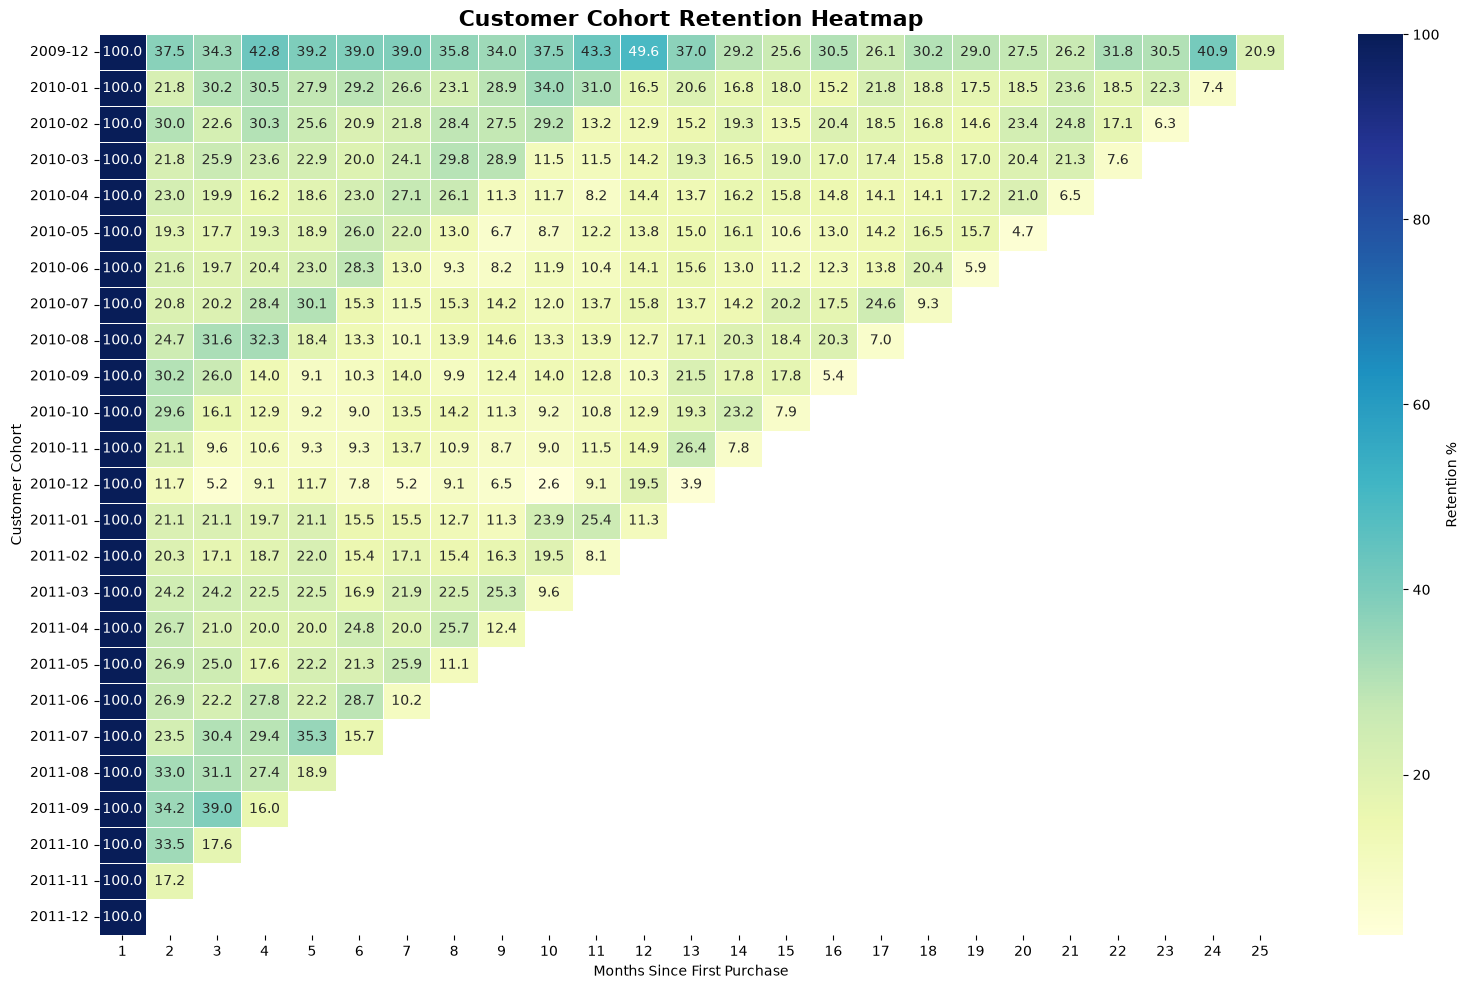

In [59]:
# ==========================================
# Cohort Retention Heatmap
# ==========================================

plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Retention %"}
)

plt.title(
    "Customer Cohort Retention Heatmap",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.tight_layout()
plt.show()

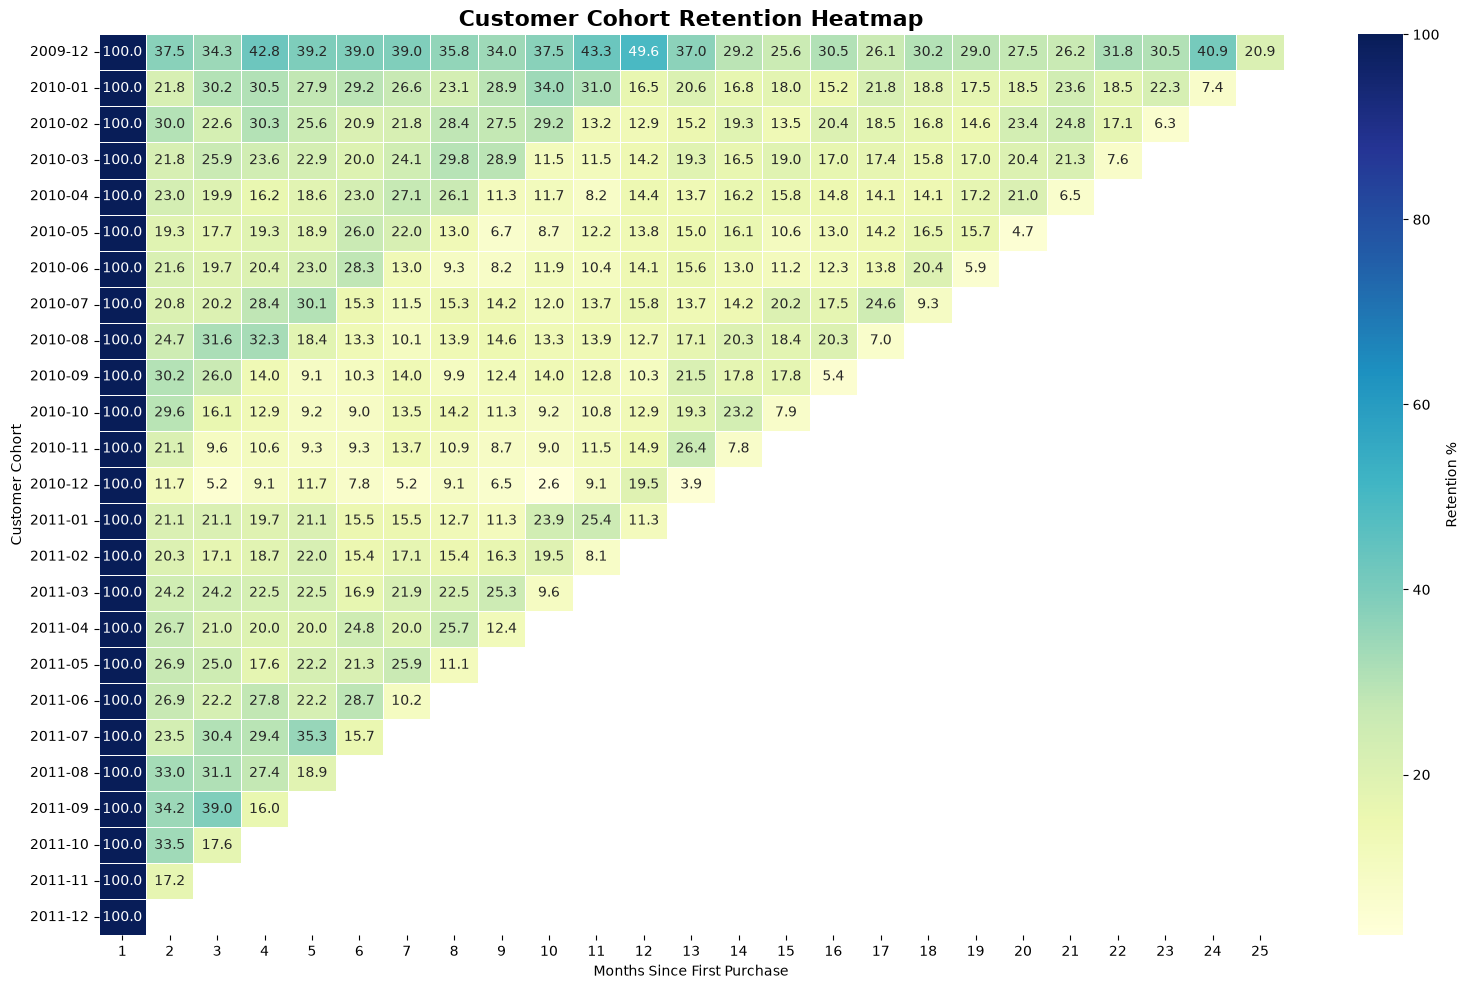

In [60]:
# ==========================================
# Save Heatmap
# ==========================================

plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Retention %"}
)

plt.title(
    "Customer Cohort Retention Heatmap",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.tight_layout()

plt.savefig(
    "../visuals/cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()